In [1]:
import os
import pandas as pd
import random
import shutil

data_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\data\participants\1\extracted signals'

In [2]:
os.chdir("..") 
from src import feature_extraction, models, utils, results

exclude = ['oral prep 0']
df, class_map = feature_extraction.make_df(data_path, exclude)

df

substance volume         1                                            \
                           min       max        mav        rms       zcr   
0           0     10  -89.8215   73.5244  10.123081  15.526914  0.271271   
1           0     10 -113.9200   86.1073   9.896790  16.791919  0.290290   
2           0     10  -82.3953   84.7438  10.532140  16.572327  0.274274   
3           0     10 -194.0030  125.6940  11.846242  20.842131  0.250250   
4           0     10 -117.7260   84.5021  11.854229  18.994828  0.257257   
..        ...    ...       ...       ...        ...        ...       ...   
440        10     20  -69.3289   69.5755  10.175371  15.426147  0.279279   
441        10     20  -86.3076   74.0248  11.288252  18.020237  0.273273   
442        10     20  -93.5527   91.9620  11.081596  17.163182  0.254254   
443        10     20  -95.3684   61.4933  11.031382  16.758005  0.288288   
444        10     20  -95.7571   91.9919  13.782139  20.737838  0.265265   

                                    ...            22                 \
       variance  ssc     abs_diffs  ...      variance  ssc abs_diffs   
0    241.085047  432   8511.370464  ...  2.147730e+07  130    426580   
1    281.968302  440   8262.519721  ...  2.476357e+07  117    449540   
2    274.641479  427   8938.223938  ...  3.078873e+07  147    391580   
3    434.394440  432   9634.231501  ...  4.119861e+07   94    458780   
4    360.801618  394   9543.440074  ...  4.449073e+07  121    353780   
..          ...  ...           ...  ...           ...  ...       ...   
440  237.965865  396   8874.451929  ...  1.854732e+07   95    329560   
441  324.728936  421   9792.563997  ...  2.879051e+07  137    396620   
442  294.572930  417   8838.968969  ...  2.811149e+07  109    390740   
443  280.830702  390   9634.328738  ...  2.616131e+07   90    390040   
444  430.057924  403  11234.928474  ...  2.290177e+07  120    462560   

                                                                            \
    mean_freq   total_power     iemg shannon_entropy median_freq peak_freq   
0    7.067688  2.855146e+07  3322060        4.040291         4.0       2.0   
1    5.096151  2.839299e+07  4038860        4.537548         2.0       1.0   
2    4.361224  2.837819e+07  4577860        4.487950         2.0       1.0   
3    8.145964  2.361374e+07  5437880        4.410476         6.0      13.0   
4    3.729602  3.530921e+07  5531540        4.641191         1.0       1.0   
..        ...           ...      ...             ...         ...       ...   
440  5.815702  2.012949e+07  3136980        3.997013         3.0       3.0   
441  5.177273  3.994745e+07  3865400        4.062512         3.0       2.0   
442  4.827547  3.174081e+07  4293940        4.641988         3.0       3.0   
443  5.345078  3.482336e+07  3813460        4.344892         4.0       2.0   
444  5.978335  2.527296e+07  3783080        4.518855         4.0       3.0   

                
     bandwidth  
0    11.468772  
1    10.656156  
2     9.277570  
3     8.524833  
4     7.157294  
..         ...  
440   6.709104  
441   7.256091  
442   7.216130  
443   6.659081  
444   9.129009  

[445 rows x 332 columns]

In [3]:
print(class_map)

{'apple': 0, 'carrot': 1, 'chewing': 2, 'dry swallow': 3, 'grape': 4, 'jelly': 5, 'milk': 6, 'popcorn': 7, 'redu oral prep': 8, 'water': 9, 'yogurt': 10}


C:\Users\chloe\AppData\Local\Temp\ipykernel_56720\3829727420.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


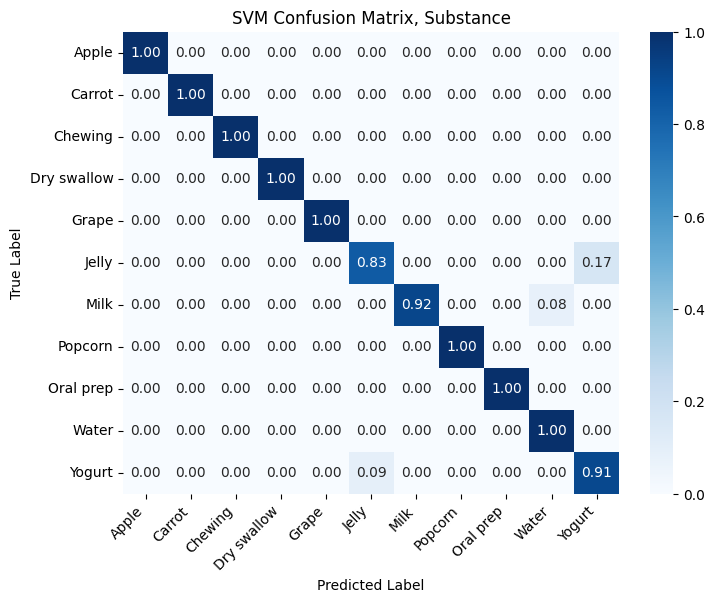

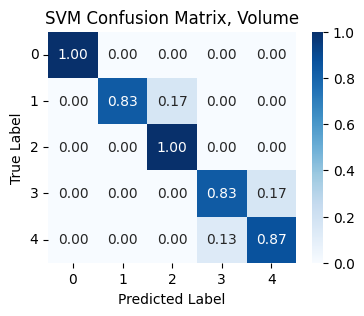

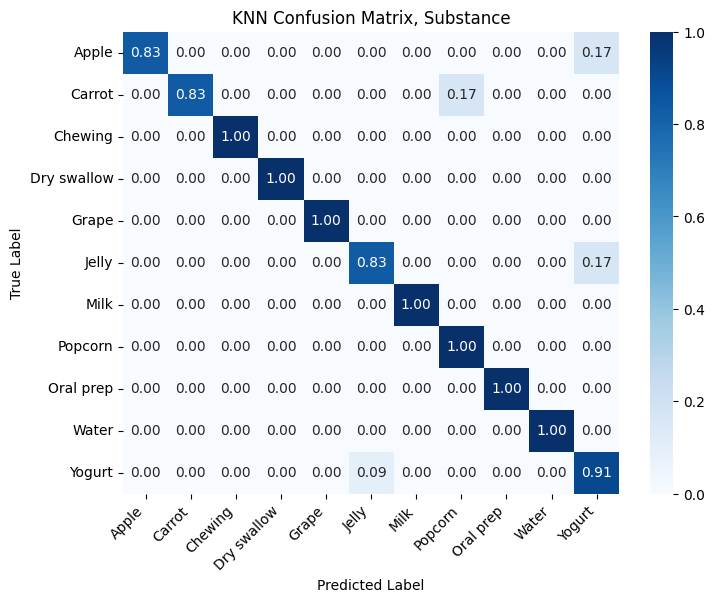

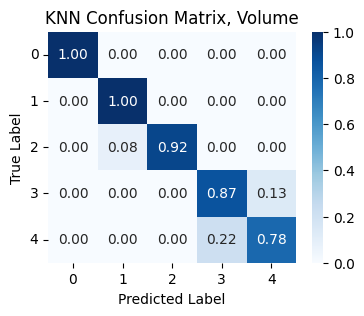

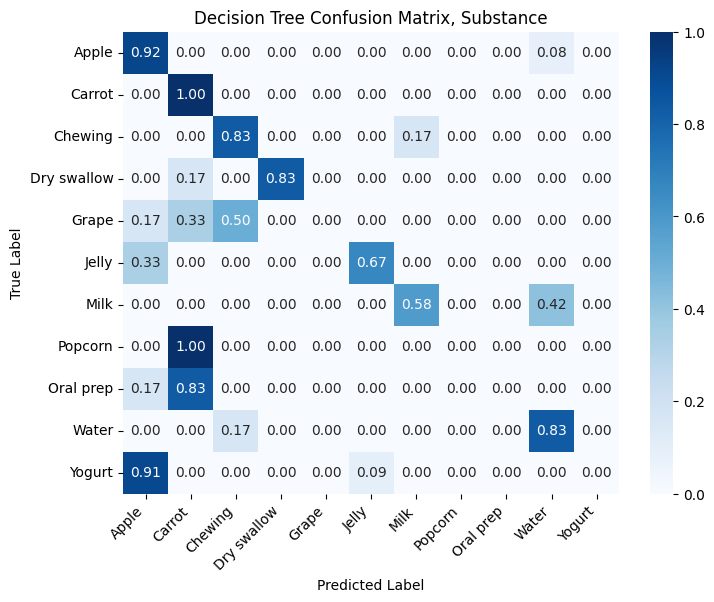

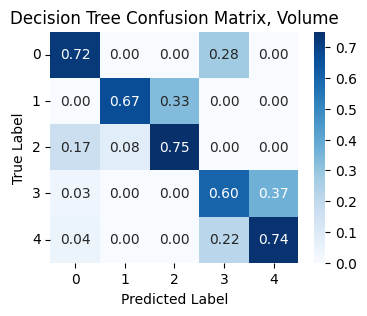

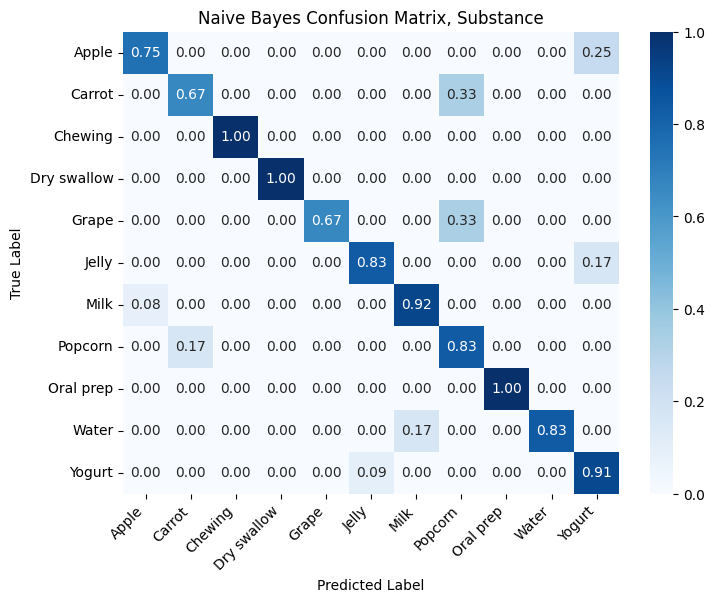

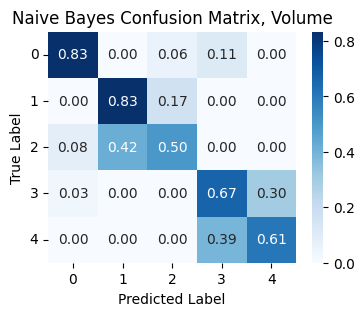

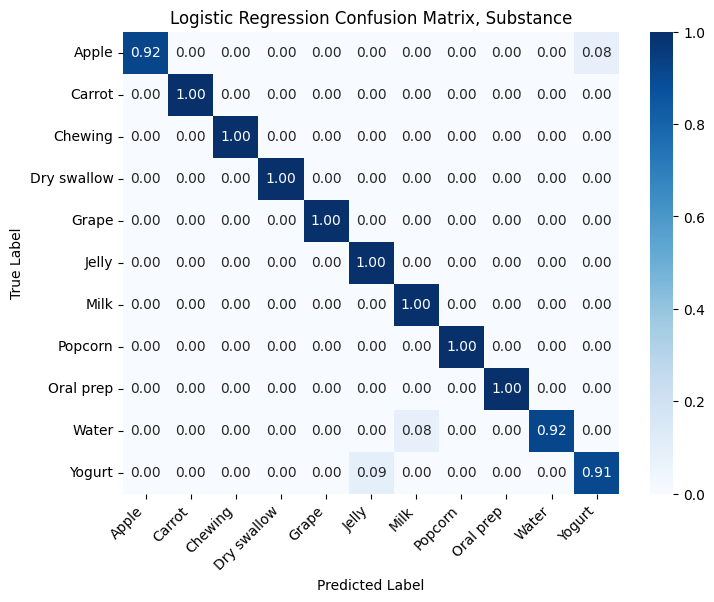

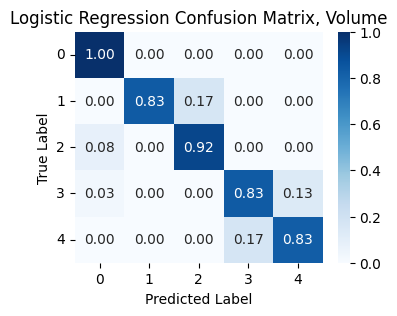

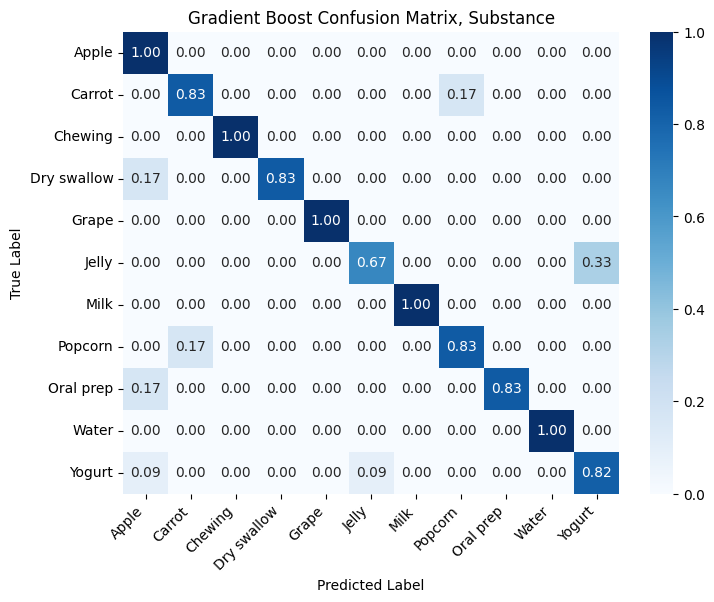

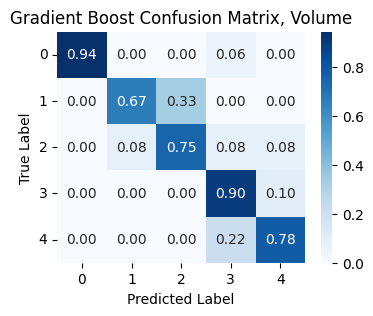

SVM
Exact Match Accuracy: 88.7640
Per-Label Accuracies: [96.62921348 89.88764045]
----------------------------
KNN
Exact Match Accuracy: 88.7640
Per-Label Accuracies: [94.38202247 88.76404494]
----------------------------
Decision Tree
Exact Match Accuracy: 38.2022
Per-Label Accuracies: [53.93258427 68.53932584]
----------------------------
Naive Bayes
Exact Match Accuracy: 60.6742
Per-Label Accuracies: [85.39325843 67.41573034]
----------------------------
Logistic Regression
Exact Match Accuracy: 85.3933
Per-Label Accuracies: [96.62921348 87.64044944]
----------------------------
Gradient Boost
Exact Match Accuracy: 78.6517
Per-Label Accuracies: [91.01123596 84.26966292]
----------------------------


In [4]:
x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]
exact_accuracies, label_accuracies = models.train_multioutput_models(x, y, class_map,random_state=42, show_cm=True, show_metrics=True)

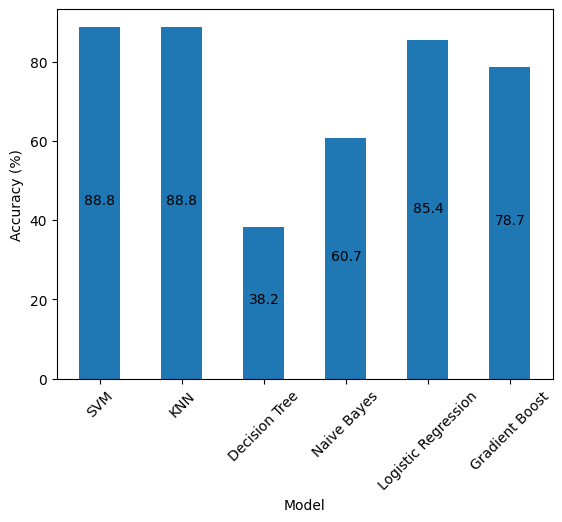

In [5]:
results.plot_acc(exact_accuracies)

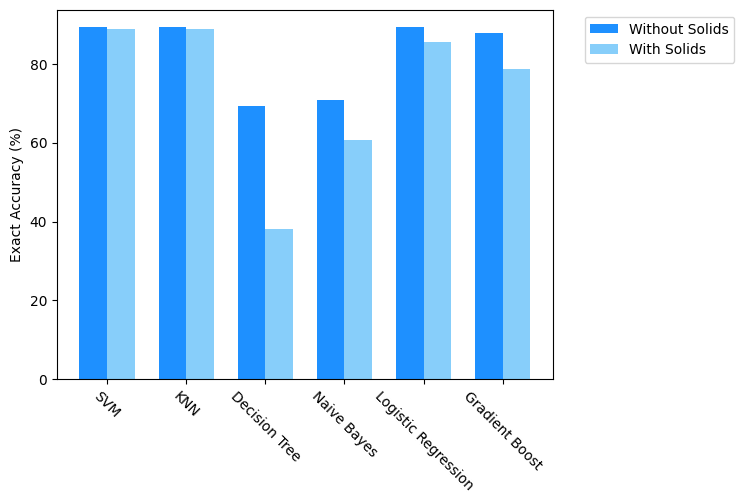

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from src.models import single_models

bandpass_accuracies_df = pd.read_csv('outputs/classification/bandpass_accuracies.csv', header=None)
bandpass_accuracies = bandpass_accuracies_df.iloc[0].tolist()

x = np.arange(len(single_models))  # [0, 1, 2]
width = 0.35  # width of each bar

# Plot bars side by side
plt.bar(x - width/2, bandpass_accuracies, width, label='Without Solids', color='dodgerblue')
plt.bar(x + width/2, exact_accuracies, width, label='With Solids', color='lightskyblue')

# Add labels
model_names = [name for name, _ in single_models]

plt.xticks(x, model_names, rotation=-45)
plt.ylabel('Exact Accuracy (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

In [7]:
import csv

output_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\outputs\classification\all_substance_accuracies.csv'

with open(output_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(exact_accuracies)